<a href="https://colab.research.google.com/github/oisiipasuta/music_preference_reserch/blob/main/%E6%A5%BD%E6%9B%B2%E9%81%B8%E5%87%BA_comp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/実験用楽曲データ作成（手作り）/acoustic_features_whole.csv')
display(df.head())
print(df.isnull().sum())

,filename,rms,spectral_centroids,spectral_bandwidth,spectral_rolloff,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,chroma_mean_D,chroma_mean_D#,chroma_mean_E,chroma_mean_F,chroma_mean_F#,chroma_mean_G,chroma_mean_G#,chroma_mean_A,chroma_mean_A#,chroma_mean_B
0,4361中_一定0_2x中,0.086683,2338.548859,3072.460259,4947.888011,-244.60947,147.53348,-11.589661,47.813587,-11.839340,...,0.207065,0.298755,0.639111,0.275838,0.167967,0.199051,0.200265,0.182823,0.178733,0.274818
1,4361中_一定0_2x大,0.086693,2459.148923,3133.289605,5177.942599,-238.44048,144.67245,-12.940132,48.444160,-12.700476,...,0.200997,0.297751,0.634766,0.275356,0.172157,0.203521,0.205968,0.191434,0.177823,0.271335
2,4361中_一定0_2x小,0.084644,1873.067253,2450.249798,3815.243089,-271.41330,166.13542,-13.992412,42.099655,-9.483488,...,0.216881,0.307218,0.652227,0.289543,0.166515,0.186503,0.178944,0.160457,0.166494,0.274580
3,4361中_一定0_drumn中,0.082511,2252.612283,3005.246255,4690.090972,-269.77190,150.14194,1.889258,32.047665,-11.998518,...,0.223040,0.312073,0.660884,0.295452,0.161604,0.180024,0.174185,0.159994,0.176516,0.285014
4,4361中_一定0_drumn大,0.083327,2238.573322,2925.990766,4652.265327,-262.07693,151.79042,-6.154371,37.770306,-12.583860,...,0.208908,0.300242,0.648869,0.284478,0.165057,0.191060,0.189757,0.174772,0.179346,0.283908


filename              0
rms                   0
spectral_centroids    0
spectral_bandwidth    0
spectral_rolloff      0
mfcc_0                0
mfcc_1                0
mfcc_2                0
mfcc_3                0
mfcc_4                0
mfcc_5                0
mfcc_6                0
mfcc_7                0
mfcc_8                0
mfcc_9                0
mfcc_10               0
mfcc_11               0
mfcc_12               0
mfcc_13               0
mfcc_14               0
mfcc_15               0
mfcc_16               0
mfcc_17               0
mfcc_18               0
mfcc_19               0
zcr                   0
low_peaks             0
middle_peaks          0
high_peaks            0
super_high_peaks      0
chroma_mean_C         0
chroma_mean_C#        0
chroma_mean_D         0
chroma_mean_D#        0
chroma_mean_E         0
chroma_mean_F         0
chroma_mean_F#        0
chroma_mean_G         0
chroma_mean_G#        0
chroma_mean_A         0
chroma_mean_A#        0
chroma_mean_B   

In [ ]:
#主成分分析を行う
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#数値データとfilenameを切り分ける
col_num = df.iloc[:, 1:].columns

df_num = df[col_num]
df_name = df['filename']

#標準化する
scaler = StandardScaler()
df_scaler = scaler.fit_transform(df_num)

#主成分分析する
n_comp = 7
pca = PCA(n_components=n_comp)
df_pca = pca.fit_transform(df_scaler)
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(n_comp)])

def split_metadata(df):
    df['harmony'] = df['filename'].apply(lambda x: x.split('_')[0])
    df['melody'] = df['filename'].apply(lambda x: x.split('_')[1])
    df['rhythm'] = df['filename'].apply(lambda x: x.split('_')[2])
    return df

df_final = df_pca.copy()
df_final['filename'] = df_name
df_final = split_metadata(df_final)
display(df_final.head())
#以降で各種情報を出力する

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,filename,harmony,melody,rhythm
0,4.859764,4.609546,4.082639,1.204484,1.753330,2.177085,1.238263,4361中_一定0_2x中,4361中,一定0,2x中
1,5.582600,4.520650,3.629085,0.820856,2.033143,1.723758,1.222517,4361中_一定0_2x大,4361中,一定0,2x大
2,0.623730,4.363242,3.930887,2.228263,2.003827,2.663163,0.806198,4361中_一定0_2x小,4361中,一定0,2x小
3,0.525530,4.492249,2.149991,-0.218717,3.126363,-0.372779,3.252083,4361中_一定0_drumn中,4361中,一定0,drumn中
4,1.152177,4.237613,2.036803,0.236783,3.476902,-0.080181,2.539778,4361中_一定0_drumn大,4361中,一定0,drumn大


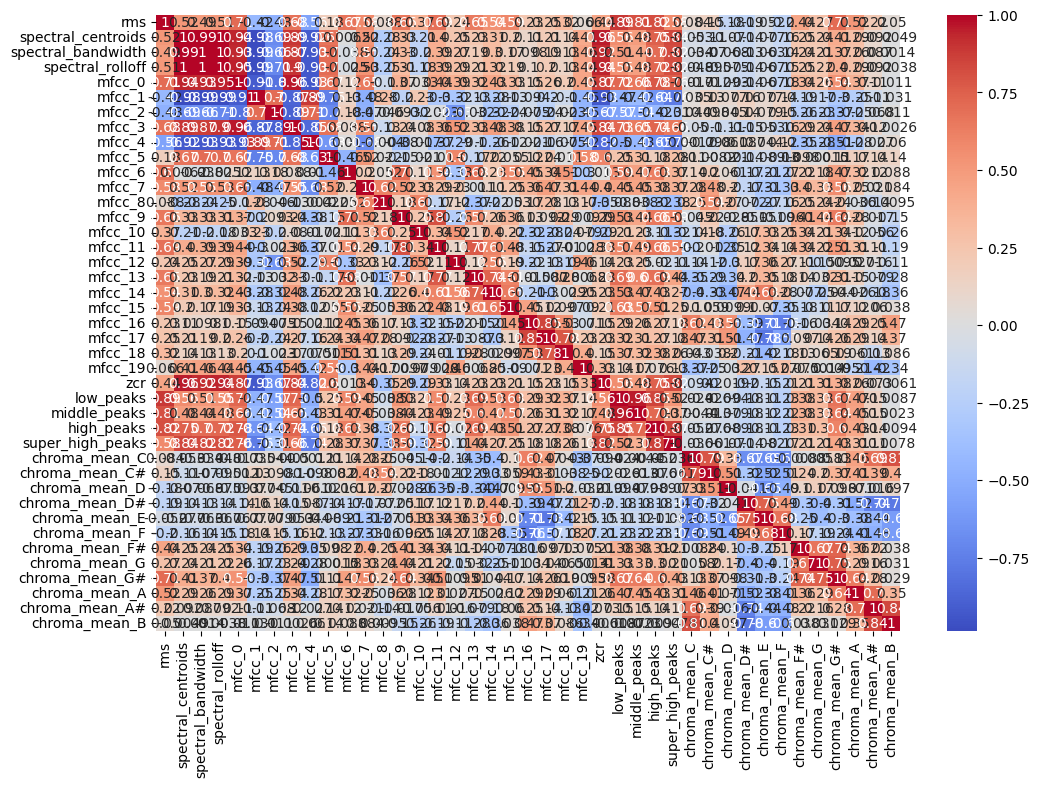

In [ ]:
# 特徴量の相関行列を計算
df_scaler = pd.DataFrame(df_scaler, columns=col_num)
corr_matrix = df_scaler.corr()
# 相関行列のヒートマップを表示
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#主成分寄与率
print("主成分寄与率：", pca.explained_variance_ratio_)
print('累積寄与率：', np.cumsum(pca.explained_variance_ratio_))

主成分寄与率： [0.33754087 0.17635746 0.12436146 0.08329255 0.06960312 0.06423221
 0.04003051]
累積寄与率： [0.33754087 0.51389833 0.63825979 0.72155234 0.79115545 0.85538766
 0.89541817]


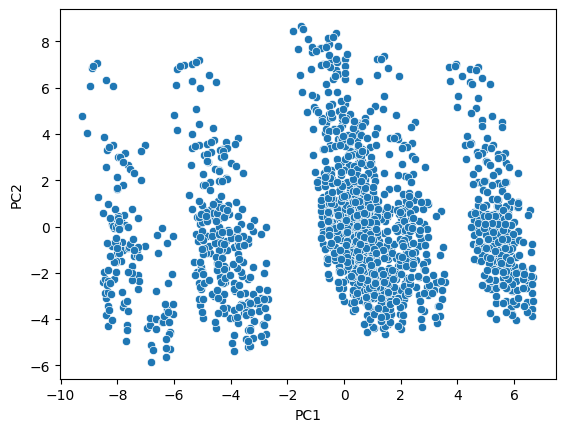

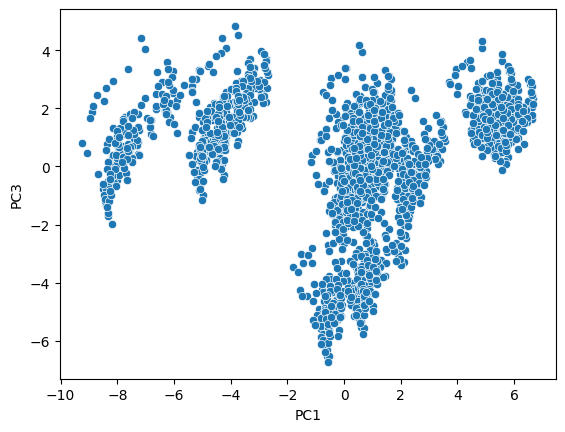

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26119 (\N{CJK UNIFIED IDEOGRAPH-6607}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.canvas

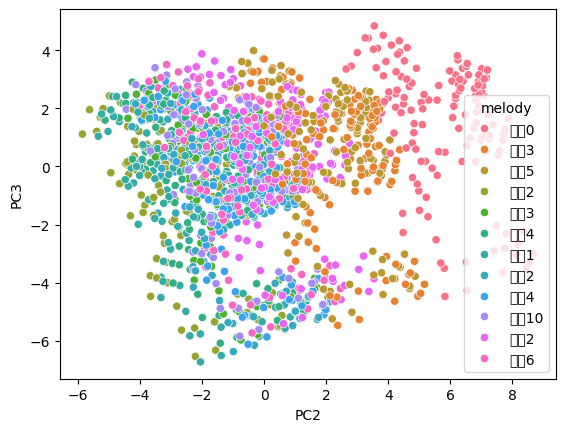

In [ ]:
#pc1, pc2でプロット
sns.scatterplot(data=df_final, x='PC1', y='PC2')
plt.show()

#pc1, pc3でプロット
sns.scatterplot(data=df_final, x='PC1', y='PC3')
plt.show()

#pc2, pc3でプロット
sns.scatterplot(data=df_final, x='PC2', y='PC3', hue='melody')
plt.show()

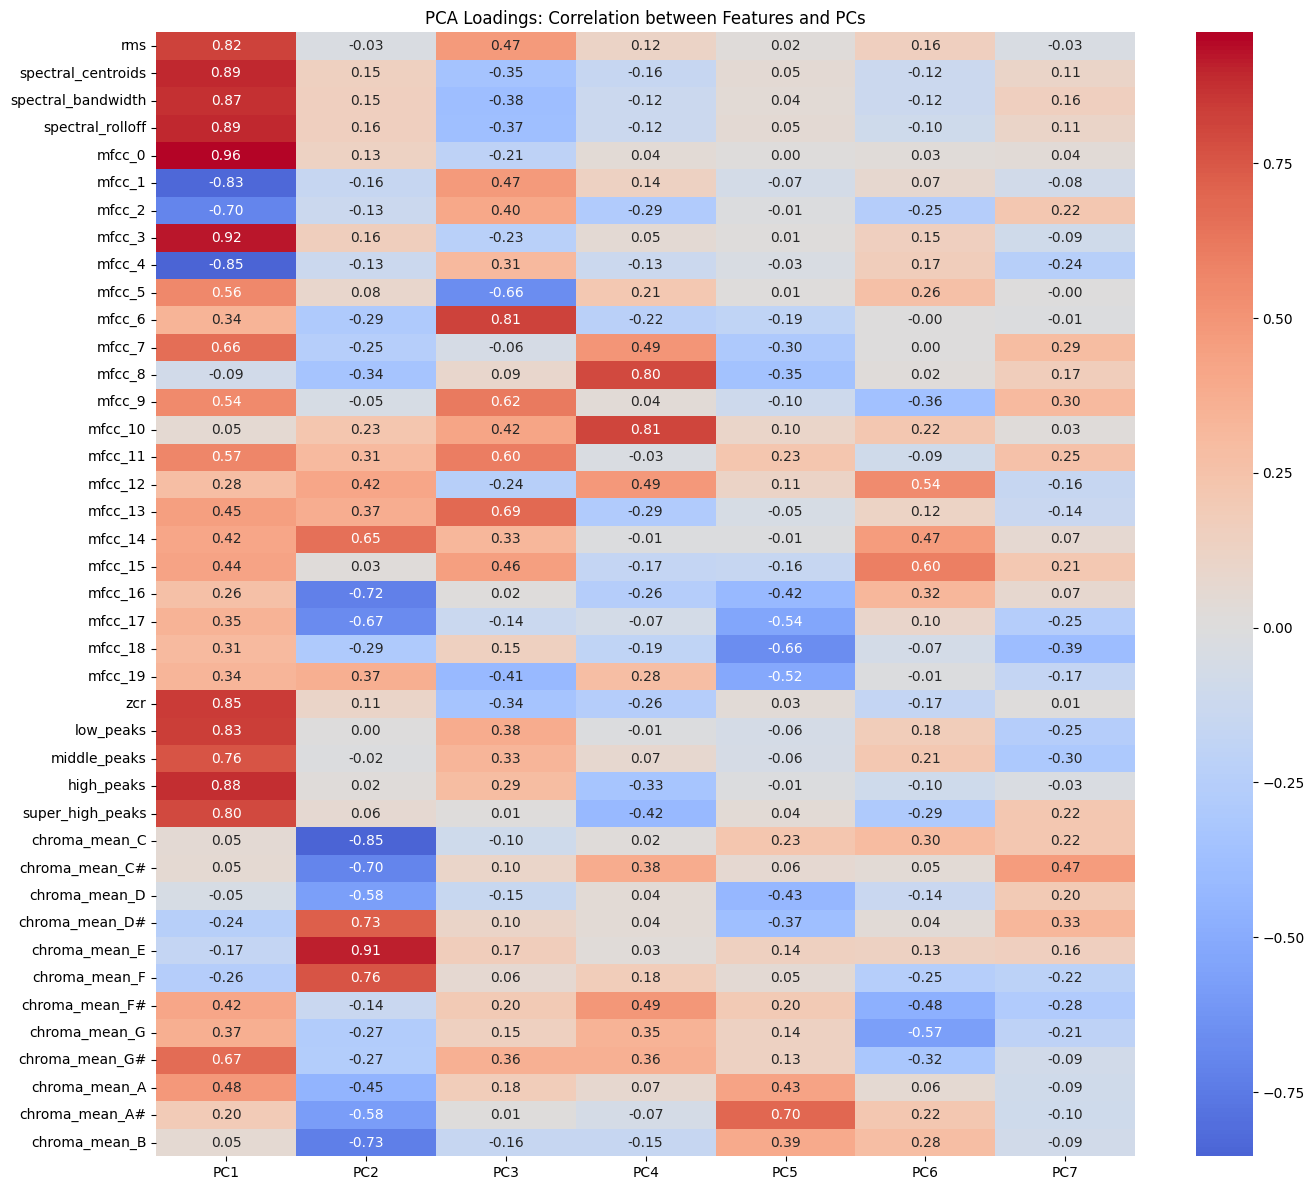

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# PC1〜PC4まで表示
n_pc_show = 7

# 相関loadingを計算
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loading_df = pd.DataFrame(
    loadings[:, :n_pc_show],
    index=col_num,
    columns=[f"PC{i}" for i in range(1, n_pc_show + 1)]
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    loading_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings: Correlation between Features and PCs")
plt.tight_layout()
plt.show()

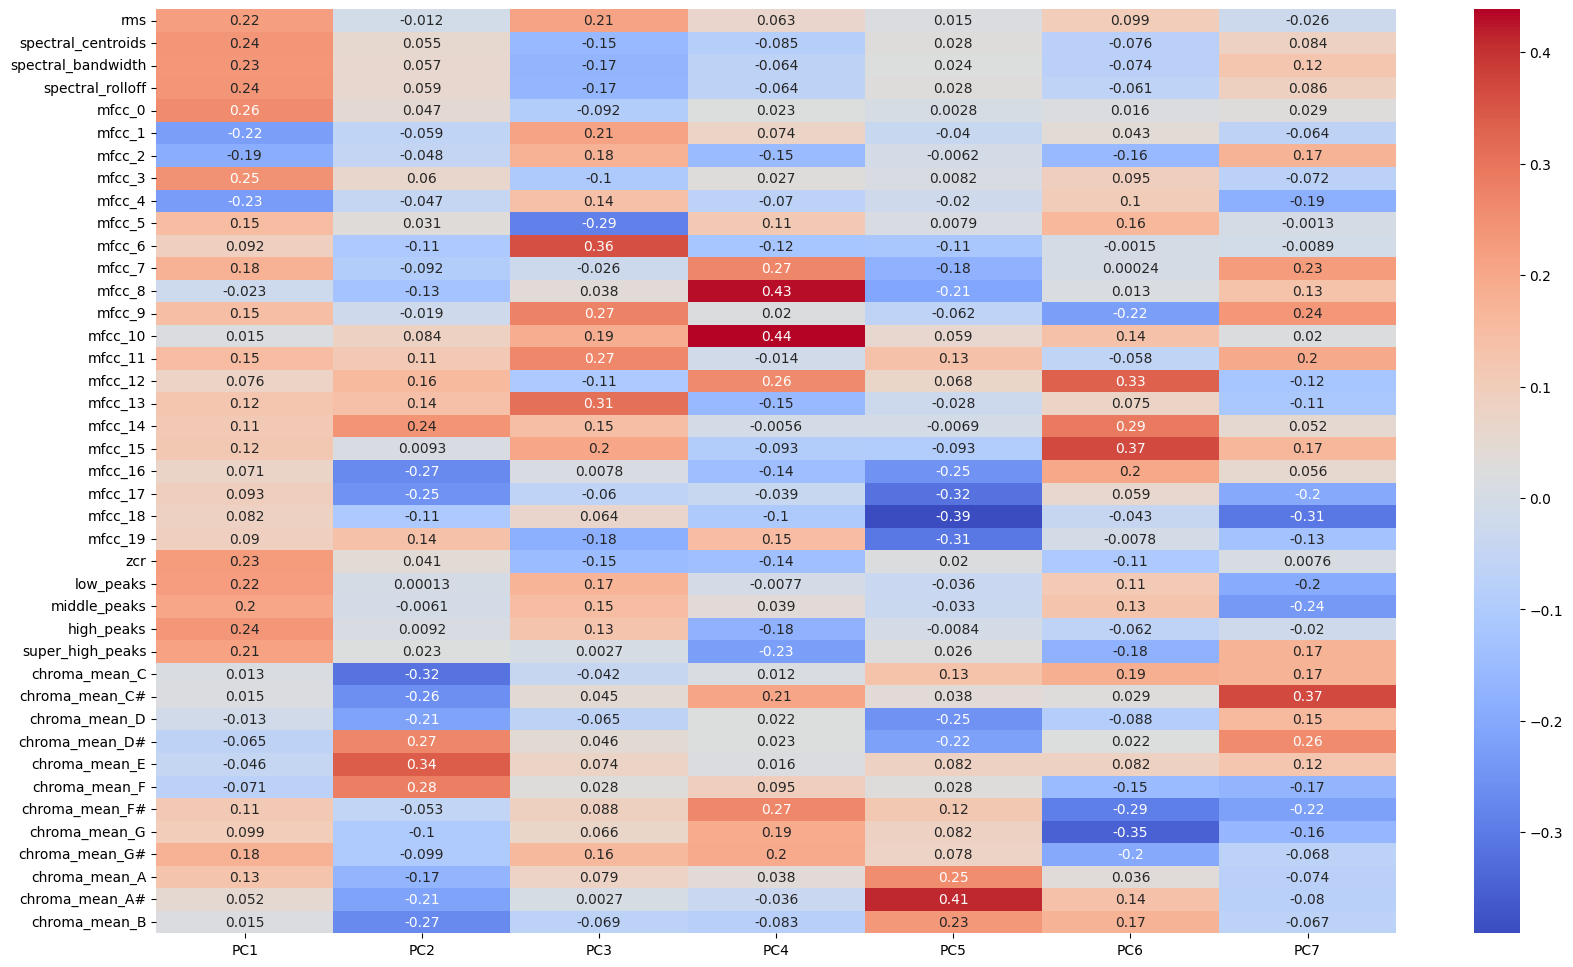

In [ ]:
#主成負荷量を計算
#ローディングスコアの表示
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(1, len(pca.components_) + 1)],
    index=col_num)
plt.figure(figsize=(20, 12))
sns.heatmap(loadings, annot=True, cmap='coolwarm')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

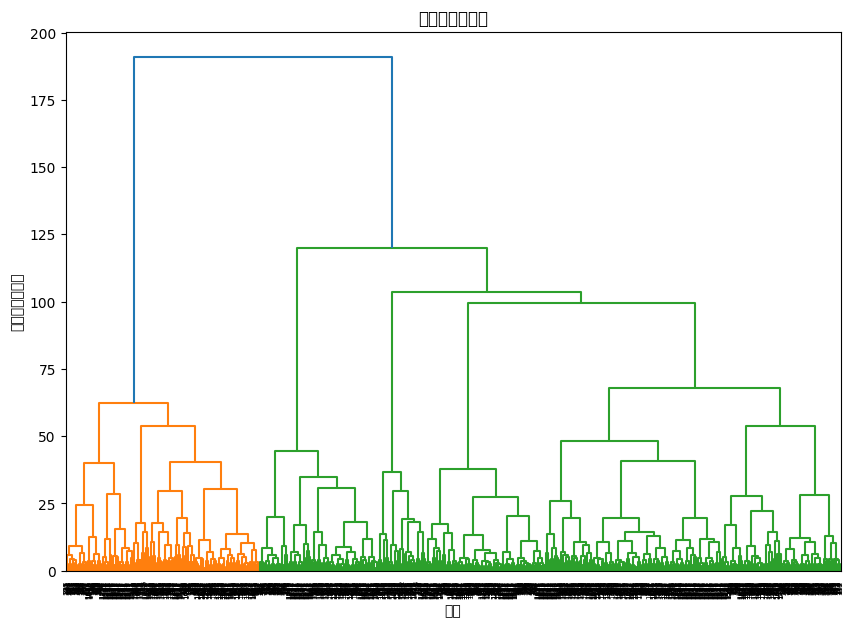

In [ ]:
# データから距離行列を計算してlinkageを実行
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(df_pca, method='ward')

# デンドログラムの表示
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('デンドログラム')
plt.xlabel('個人')
plt.ylabel('クラスタ間距離')
plt.show()


cluster_den
5    660
1    432
4    264
2    264
3    108
Name: count, dtype: int64


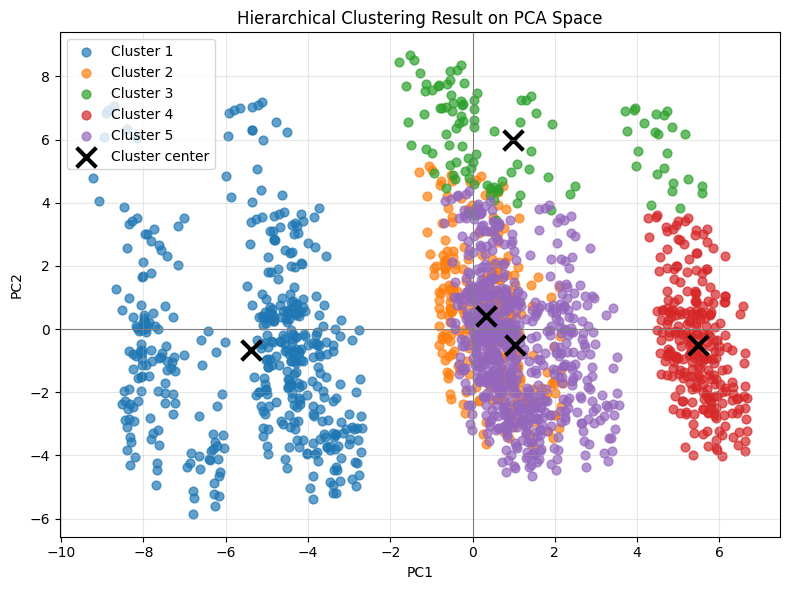

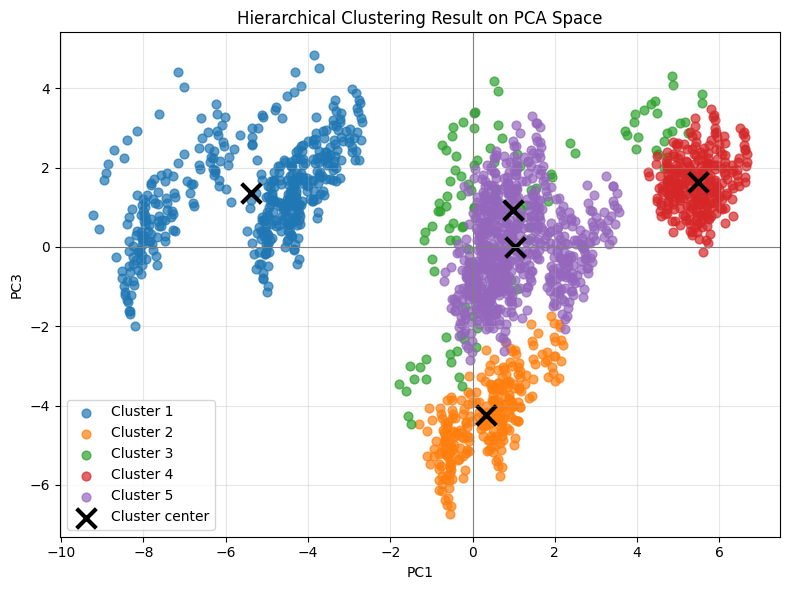

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

# クラスタ分けするしきい値を決める。3分割したいので25に設定。
threshold = 75
linkage_array = linkage(df_pca, method='ward', metric='euclidean')

# クラスタリング結果の値を取得
df_final['cluster_den'] = fcluster(linkage_array, threshold, criterion='distance')
print(df_final['cluster_den'].value_counts())



# =========================
# PC1-PC2にクラスタ結果をプロット
# =========================

plt.figure(figsize=(8, 6))

for cluster_id, group in df_final.groupby('cluster_den'):
    plt.scatter(
        group['PC1'],
        group['PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        s=40
    )

# 各クラスタの重心を表示
centers = df_final.groupby('cluster_den')[['PC1', 'PC2']].mean()

plt.scatter(
    centers['PC1'],
    centers['PC2'],
    marker='x',
    s=200,
    linewidths=3,
    color='black',
    label='Cluster center'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clustering Result on PCA Space')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# PC1-PC2にクラスタ結果をプロット
# =========================

plt.figure(figsize=(8, 6))

for cluster_id, group in df_final.groupby('cluster_den'):
    plt.scatter(
        group['PC1'],
        group['PC3'],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        s=40
    )

# 各クラスタの重心を表示
centers = df_final.groupby('cluster_den')[['PC1', 'PC3']].mean()

plt.scatter(
    centers['PC1'],
    centers['PC3'],
    marker='x',
    s=200,
    linewidths=3,
    color='black',
    label='Cluster center'
)

plt.xlabel('PC1')
plt.ylabel('PC3')
plt.title('Hierarchical Clustering Result on PCA Space')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# =========================
# 1. PCAスコアをdf_finalに追加
# =========================

df_select = df_final.copy()

n_pc = 7  # クラスタリングに使った主成分数に合わせる
pc_cols = [f"PC{i}" for i in range(1, n_pc + 1)]

for i, col in enumerate(pc_cols):
    df_select[col] = df_pca.iloc[:, i].values


# =========================
# 2. 標準化なしで各クラスタから5曲選出
# =========================

def select_songs_per_cluster_by_quantile(
    data,
    pc_cols,
    cluster_col="cluster_den",
    target_quantiles=None
):
    if target_quantiles is None:
        target_quantiles = {
            "center": 0.0,
            "middle": 0.5,
            "outer": 0.8
        }

    selected_rows = []

    for cluster_id, cluster_df in data.groupby(cluster_col):
        cluster_df = cluster_df.copy()

        if len(cluster_df) < len(target_quantiles):
            print(f"Warning: Cluster {cluster_id} has fewer than {len(target_quantiles)} songs.")
            continue

        X = cluster_df[pc_cols].values
        center = X.mean(axis=0)

        cluster_df["distance_to_center"] = np.linalg.norm(X - center, axis=1)

        already_selected = []

        for level, q in target_quantiles.items():
            candidates = cluster_df[~cluster_df.index.isin(already_selected)].copy()

            target_distance = cluster_df["distance_to_center"].quantile(q)

            candidates["target_level"] = level
            candidates["target_quantile"] = q
            candidates["target_distance"] = target_distance
            candidates["diff_from_target"] = np.abs(
                candidates["distance_to_center"] - target_distance
            )

            selected_idx = candidates["diff_from_target"].idxmin()
            already_selected.append(selected_idx)

            selected_row = cluster_df.loc[[selected_idx]].copy()
            selected_row["target_level"] = level
            selected_row["target_quantile"] = q
            selected_row["target_distance"] = target_distance
            selected_row["diff_from_target"] = np.abs(
                selected_row["distance_to_center"] - target_distance
            )

            selected_rows.append(selected_row)

    return pd.concat(selected_rows, axis=0).reset_index(drop=True)


selected_songs = select_songs_per_cluster_by_quantile(
    data=df_select,
    pc_cols=pc_cols,
    cluster_col="cluster_den",
    target_quantiles={
        "center": 0.0,
        "middle": 0.5,
        "outer": 0.8
    }
)

selected_songs

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,filename,harmony,melody,rhythm,cluster_den,distance_to_center,target_level,target_quantile,target_distance,diff_from_target
0,-4.501533,-0.666441,1.137089,0.171145,-1.281802,0.531850,-0.422191,4563小_上昇3_drumn小,4563小,上昇3,drumn小,1,1.489423,center,0.0,1.489423,0.000000
1,-3.542315,-3.747471,2.065448,1.264498,0.399504,1.856702,0.760103,4361大_下降2_shuffle小,4361大,下降2,shuffle小,1,4.269694,middle,0.5,4.270802,0.001108
2,-7.167867,2.026251,2.122555,1.866331,0.844191,-3.011396,-2.346277,4536小_一定5_half小,4536小,一定5,half小,1,5.459978,outer,0.8,5.458683,0.001295
3,0.968316,0.487032,-3.908112,2.164768,-0.898676,0.731157,-0.352985,4536小_上昇3_half大,4536小,上昇3,half大,2,1.223509,center,0.0,1.223509,0.000000
4,0.356072,-0.404912,-5.149041,-0.295692,-1.337117,2.268659,-0.314620,4563大_下降1_half大,4563大,下降1,half大,2,3.505076,middle,0.5,3.484125,0.020951
5,-0.792346,4.558555,-4.058177,1.897605,-0.229020,1.427043,-0.598441,4563小_一定3_half中,4563小,一定3,half中,2,4.444029,outer,0.8,4.456428,0.012399
6,1.553502,6.840986,1.495964,-1.344730,0.905119,1.536380,1.988390,4563小_一定0_shuffle大,4563小,一定0,shuffle大,3,1.576114,center,0.0,1.576114,0.000000
7,3.968754,5.150655,2.475313,-1.725204,1.861143,3.035776,-0.096972,6451大_一定0_2x中,6451大,一定0,2x中,3,4.266775,middle,0.5,4.259538,0.007236
8,5.048010,3.844724,3.118278,0.022259,2.321925,2.074476,1.520976,4361大_一定0_2x大,4361大,一定0,2x大,3,5.184708,outer,0.8,5.145894,0.038814
9,5.992123,-0.547950,1.471171,-0.095300,-1.022242,0.472751,-0.934408,4536小_上昇3_2x大,4536小,上昇3,2x大,4,0.801164,center,0.0,0.801164,0.000000


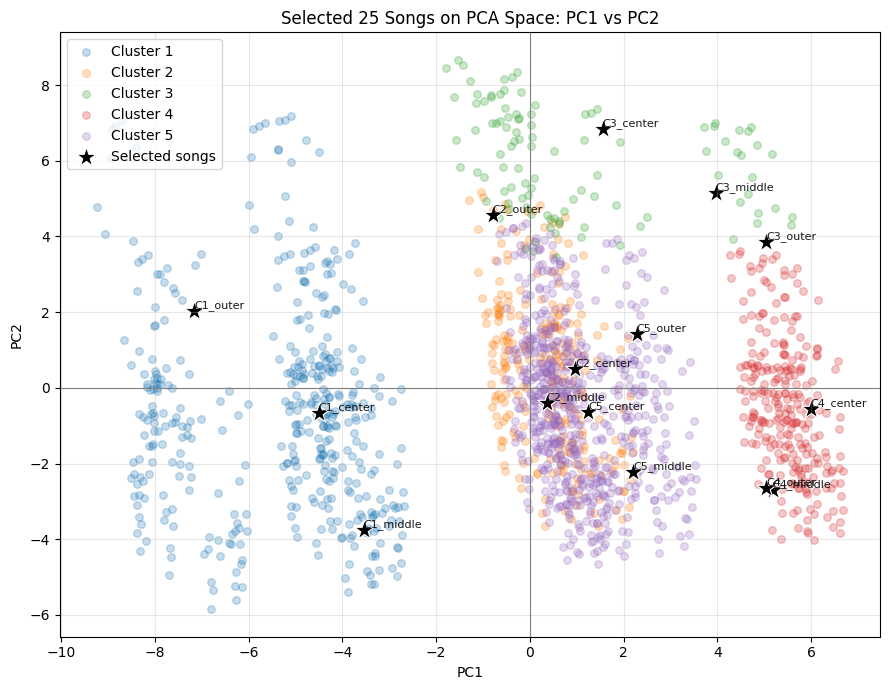

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

# =========================
# 1. 全曲をクラスタごとに薄く表示
# =========================

for cluster_id, group in df_select.groupby("cluster_den"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.25,
        s=30
    )

# =========================
# 2. 選出した20曲を強調表示
# =========================

plt.scatter(
    selected_songs["PC1"],
    selected_songs["PC2"],
    color="black",
    marker="*",
    s=220,
    label="Selected songs",
    edgecolors="white",
    linewidths=0.8
)

# =========================
# 3. 選出曲にラベルを付ける
# =========================

for _, row in selected_songs.iterrows():
    label = f"C{row['cluster_den']}_{row['target_level']}"

    plt.text(
        row["PC1"],
        row["PC2"],
        label,
        fontsize=8,
        ha="left",
        va="bottom",
        alpha=0.9
    )

# =========================
# 4. 図の装飾
# =========================

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Selected 25 Songs on PCA Space: PC1 vs PC2")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

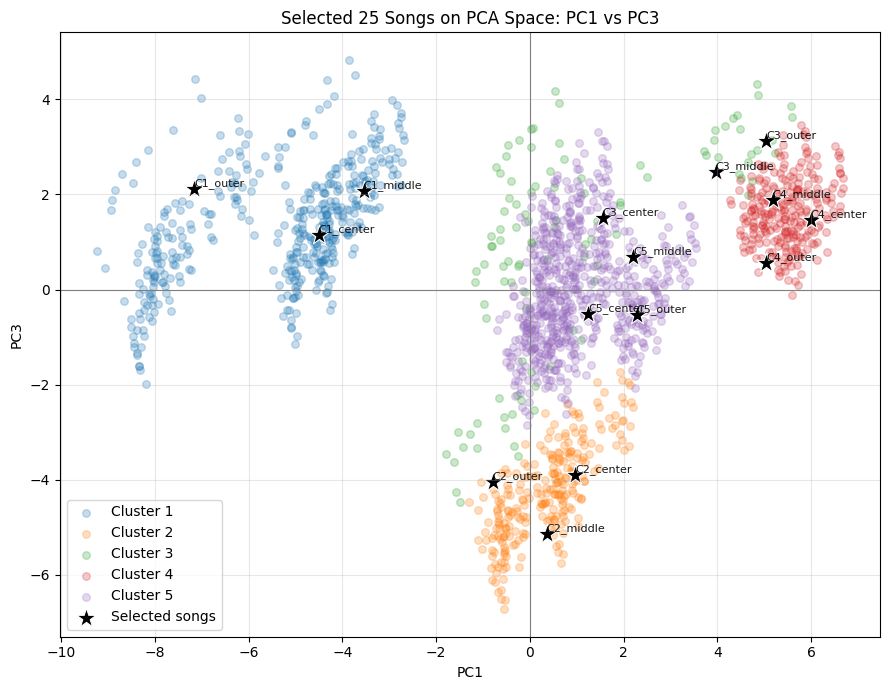

In [ ]:
plt.figure(figsize=(9, 7))

# =========================
# 1. 全曲をクラスタごとに薄く表示
# =========================

for cluster_id, group in df_select.groupby("cluster_den"):
    plt.scatter(
        group["PC1"],
        group["PC3"],
        label=f"Cluster {cluster_id}",
        alpha=0.25,
        s=30
    )

# =========================
# 2. 選出した20曲を強調表示
# =========================

plt.scatter(
    selected_songs["PC1"],
    selected_songs["PC3"],
    color="black",
    marker="*",
    s=220,
    label="Selected songs",
    edgecolors="white",
    linewidths=0.8
)

# =========================
# 3. 選出曲にラベルを付ける
# =========================

for _, row in selected_songs.iterrows():
    label = f"C{row['cluster_den']}_{row['target_level']}"

    plt.text(
        row["PC1"],
        row["PC3"],
        label,
        fontsize=8,
        ha="left",
        va="bottom",
        alpha=0.9
    )

# =========================
# 4. 図の装飾
# =========================

plt.xlabel("PC1")
plt.ylabel("PC3")
plt.title("Selected 25 Songs on PCA Space: PC1 vs PC3")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
meta_cols = [
    "harmony",
    "rhythm",
    "melody"
]

for col in meta_cols:
    print("=" * 50)
    print(col)
    print(selected_songs[col].value_counts().sort_index())

harmony
harmony
4361中    1
4361大    3
4536小    4
4563大    1
4563小    3
6451大    3
Name: count, dtype: int64
rhythm
rhythm
2x中         3
2x大         2
drumn大      2
drumn小      1
half中       1
half大       2
half小       1
shuffle大    2
shuffle小    1
Name: count, dtype: int64
melody
melody
一定0    3
一定3    1
一定5    2
上昇2    1
上昇3    4
下降1    1
下降2    2
山型6    1
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


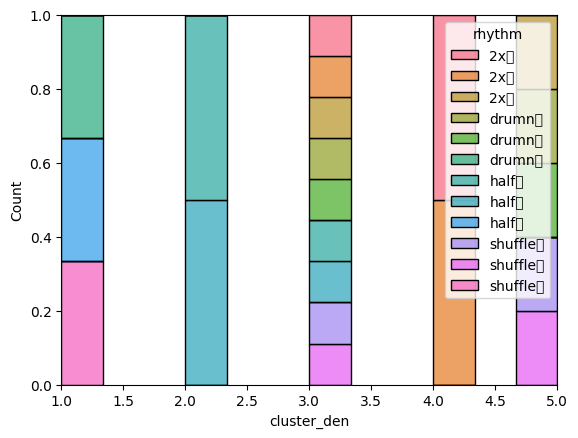

In [ ]:
clus = df_final['cluster_den']
harm = df_final['harmony']
melody = df_final['melody']
rhythm = df_final['rhythm']

sns.histplot(data=df_final, x='cluster_den', hue='rhythm', multiple='fill')
plt.show()

In [ ]:
display(selected_songs['filename'])

,filename
0,4563小_上昇3_drumn小
1,4361大_下降2_shuffle小
2,4536小_一定5_half小
3,4536小_上昇3_half大
4,4563大_下降1_half大
5,4563小_一定3_half中
6,4563小_一定0_shuffle大
7,6451大_一定0_2x中
8,4361大_一定0_2x大
9,4536小_上昇3_2x大
